In [32]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from dotenv import load_dotenv


from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random
import os

In [33]:
load_dotenv()

True

In [34]:
model = ChatOpenAI(
    model="openai/gpt-oss-20b",
    api_key=os.getenv("GROQ_API_KEY"),
    base_url= os.getenv("GROQ_BASE_URL"),
    max_tokens=300,
    temperature=0.5
)


In [58]:
# tools


search_tool = DuckDuckGoSearchRun(region="us-en")


@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}


@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    api_key=os.getenv("STOCK_API_KEY")
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={api_key}"
    r = requests.get(url)
    return r.json()


In [36]:
# make tool list
tools = [search_tool, calculator, get_stock_price]

# make the llm tool-aware
llm_with_tools = model.bind_tools(tools)

In [37]:
# state

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [46]:
# graph nodes

def chat_node(state: ChatState):
    """ LLM node that may answer or request a tool call."""

    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages':[response]}

tool_node = ToolNode(tools)  # Execute tool class

In [47]:
# graph structure

graph = StateGraph(ChatState)
graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

In [48]:
graph.add_edge(START, 'chat_node')

# if the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges('chat_node', tools_condition)

graph.add_edge('tools', 'chat_node')

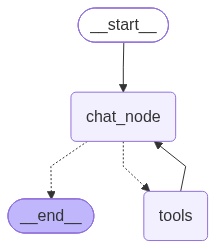

In [49]:
chatbot = graph.compile()

chatbot

In [51]:
# regular chat

output = chatbot.invoke({'messages': [HumanMessage(content='Hello!, how are you')]})

print(output['messages'][-1].content)

Hello! I'm just a bundle of code, but I'm here and ready to help you. How can I assist you today?


In [53]:
# chat requiring tool

output = chatbot.invoke({'messages': [HumanMessage(content='multipy 2 and 3 and 4')]})

print(output['messages'][-1].content)

The product of 2 × 3 × 4 is **24**.


In [54]:
# chat requiring tool

output = chatbot.invoke({'messages': [HumanMessage(content='What is the stock price of MRF')]})

print(output['messages'][-1].content)

**MRF Ltd. (NSE: MRF)**  
- **Current share price:** **₹124,580.00** per share (INR)  

*This figure is taken from the latest live quote available on major Indian market data platforms (NSE/BSE). Prices fluctuate throughout the trading day, so the value above is accurate as of the most recent update.*


In [59]:
# Chat multiple requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="First find out the stock price of MRF then find out how much will it take to purchase 50 shares?")]})
print(out["messages"][-1].content)

**MRF (Ticker: MRF) – Current Share Price (latest available)**  
- **Price:** ₹128,593.65 per share (as of the most recent data, 2 weeks ago)

**Cost to purchase 50 shares**  
\[
50 \text{ shares} \times ₹128,593.65 = ₹6,429,682.50
\]

So, it would take approximately **₹6.43 million** to buy 50 shares of MRF at the current price.


In [57]:
model.invoke("First find out the stock price of MRF then find out how much will it take to purchase 50 shares?""First find out the stock price of MRF then find out how much will it take to purchase 50 shares?")

AIMessage(content='I’m sorry, but I don’t have access to real‑time market data, so I can’t tell you the current price of MRF’s stock.  \n\nHere’s how you can find the information and calculate the cost yourself:\n\n1. **Check a reliable source for the latest price**  \n   - Visit a financial news site (e.g., Bloomberg, Reuters, MoneyControl, NSE/BSE website).  \n   - Look up the ticker symbol for MRF (usually “MRF” on the Indian stock exchanges).  \n   - Note the most recent closing price or the live bid/ask price.\n\n2. **Calculate the cost for 50 shares', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 300, 'prompt_tokens': 117, 'total_tokens': 417, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 159, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.31122736, 'prompt_time': 0.007049845, 'completion_time': 0.363004781, 'total_